In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df['target'].value_counts()

,count
target,
1,357
0,212


#Train-test split with

In [ ]:
x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42, stratify=y

)


A **Baseline Classifier** is a simple model used as a reference point to compare the performance of more complex models. It provides a benchmark to determine if a machine learning model is performing better than random chance or a very simple rule. Common baseline classifiers include:

*   **Dummy Classifier**: Predicts based on simple strategies (e.g., most frequent class, random, or stratified random).
*   **Majority Class Classifier**: Always predicts the class that appears most frequently in the training data.
*   **Random Classifier**: Makes predictions randomly.

For a classification problem, a baseline helps ensure that your sophisticated model isn't just performing at or below what a trivial approach could achieve.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize Dummy Classifier with 'most_frequent' strategy
dummy_clf = DummyClassifier(strategy='most_frequent')

# Train the classifier
dummy_clf.fit(x_train, y_train)
print("Baseline Accuracy:" , accuracy_score(y_test, dummy_clf.predict(x_test)))

Baseline Accuracy: 0.631578947368421


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

pipeline = Pipeline([
  ('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier())
])

#Hyperparameter Tuning using CSV

In [ ]:
param_grid = {
    'knn__n_neighbors': list(range(1,21)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1,2]
}

In [ ]:
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

grid.fit(x_train, y_train)
grid.best_params_

{'knn__n_neighbors': 6, 'knn__p': 1, 'knn__weights': 'uniform'}

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Test Accuracy: 0.956140350877193


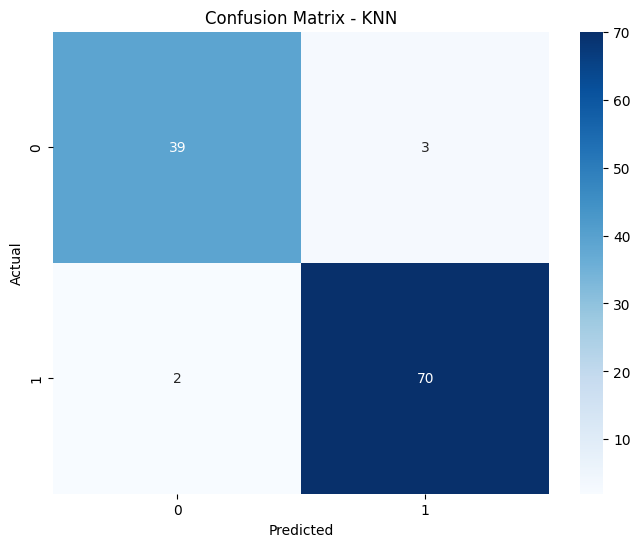

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

In [ ]:
#classification reoprt

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



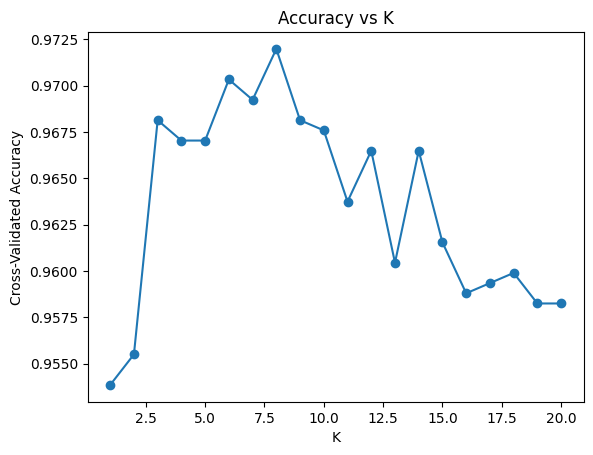

In [ ]:
cv_result = pd.DataFrame(grid.cv_results_)
accurcy_k = cv_result.groupby('param_knn__n_neighbors')['mean_test_score'].mean()
best_k = accurcy_k.idxmax()

plt.figure()
plt.plot(accurcy_k.index, accurcy_k.values, marker='o')
plt.xlabel('K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Accuracy vs K')
plt.show()

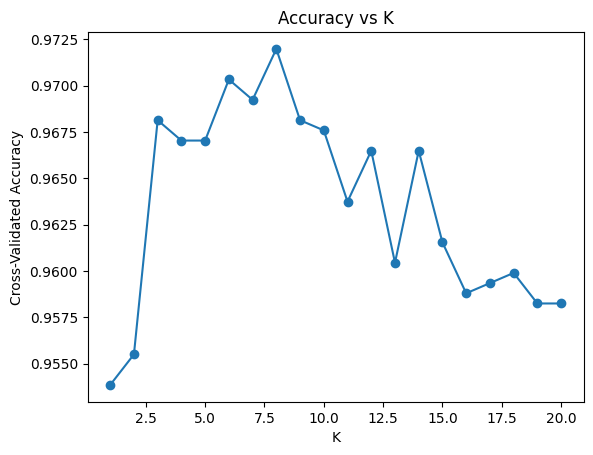

optimal K: 8


In [ ]:
cv_result = pd.DataFrame(grid.cv_results_)
accurcy_k = cv_result.groupby('param_knn__n_neighbors')['mean_test_score'].mean()
best_k = accurcy_k.idxmax()

plt.figure()
plt.plot(accurcy_k.index, accurcy_k.values, marker='o')
plt.xlabel('K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Accuracy vs K')
plt.show()

print("optimal K:", best_k)

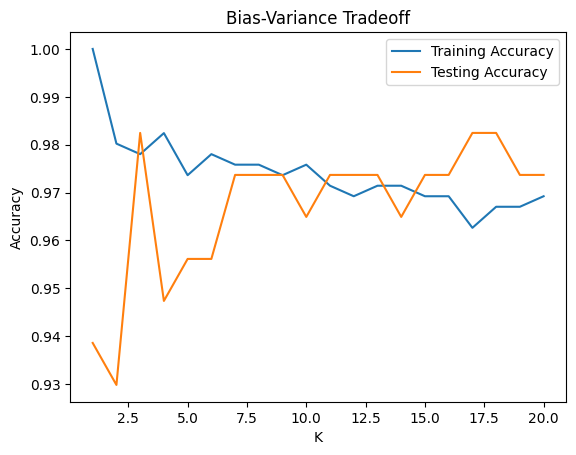

In [ ]:
k_values = range(1, 21)
train_acc, test_acc = [],[]

for k in k_values:
  # Set the n_neighbors parameter for the 'knn' step in the pipeline
  pipeline.set_params(knn__n_neighbors=k)
  pipeline.fit(x_train, y_train)
  train_acc.append(pipeline.score(x_train, y_train))
  test_acc.append(pipeline.score(x_test, y_test))

plt.figure()
plt.plot(k_values, train_acc, label='Training Accuracy')
plt.plot(k_values, test_acc, label='Testing Accuracy')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.show()